# Wildfire Severity — Modeling
**Target:** `log_acres_burned` (regression, exponentiate predictions to get acres)
**Split:** Train 2013–2021 | Test 2022–2024
**Models:** Linear Regression → Random Forest → XGBoost → Stacking Ensemble

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor

df = pd.read_csv('../data/final_dataset.csv')
df['Date'] = pd.to_datetime(df['Date'])
print(f'Loaded: {df.shape}')

Loaded: (2579, 49)


## 1. Feature Selection
Drop collinear features (|r| > 0.85 with another feature) before modeling.
When two features are redundant, keep the one with the stronger correlation to the target.

In [2]:
# Collinear pairs identified in EDA — keep the stronger predictor of each pair:
#
#  Wind Run (miles)      vs Avg Wind Speed (mph)    -> drop Wind Run (r=0.034 vs 0.034, keep mph)
#  D0, Any_Drought       vs No_Drought              -> drop D0, Any_Drought (algebraically identical)
#  Wind_Run_sum_7d       vs Avg_Wind_Speed_mean_7d  -> drop Wind_Run_sum_7d
#  Avg_Wind_Speed_max_7d vs Avg_Wind_Speed_mean_7d  -> drop max (mean stronger)
#  Avg_Soil_Temp_mean_7d vs Avg Soil Temp (F)       -> drop rolling (snapshot stronger)
#  Min_Air_Temp_min_7d   vs Min_Air_Temp_mean_7d    -> drop min_7d
#  Drought_D3_D4         vs D3                      -> drop Drought_D3_D4
#  Precip_max_7d         vs Precip_sum_7d           -> drop max (sum stronger)
#  Max_Air_Temp_mean_7d  vs Max_Air_Temp_max_7d     -> drop mean (max stronger r=0.142)
#  Drought_Score         vs D1/D2                   -> keep Drought_Score, drop D2 (D1 kept separately)
#  Avg_Temp              vs Max Air Temp (F)        -> drop Avg_Temp
#  Max_Rel_Hum_min_7d    vs Max_Rel_Hum_mean_7d     -> drop mean (min stronger)
#  ETo_sum_7d            vs Sol_Rad_mean_7d         -> keep ETo_sum_7d (stronger)
#  Min_Air_Temp_mean_7d  vs Min Air Temp (F)        -> drop rolling (snapshot stronger)

DROP_COLS = [
    'Wind Run (miles)',       # redundant with Avg Wind Speed
    'D0',                     # = Any_Drought = 100 - No_Drought
    'Any_Drought',            # algebraically identical to No_Drought
    'No_Drought',             # keep Drought_Score instead
    'Wind_Run_sum_7d',        # redundant with Avg_Wind_Speed_mean_7d
    'Avg_Wind_Speed_max_7d',  # redundant with mean
    'Avg_Soil_Temp_mean_7d',  # redundant with snapshot
    'Min_Air_Temp_min_7d',    # redundant with mean
    'Drought_D3_D4',          # redundant with D3
    'Precip_max_7d',          # redundant with sum
    'Max_Air_Temp_mean_7d',   # weaker than max_7d
    'D2',                     # high collinearity with Drought_Score
    'Avg_Temp',               # redundant with Max Air Temp
    'Max_Rel_Hum_mean_7d',    # weaker than min_7d
    'Sol_Rad_mean_7d',        # redundant with ETo_sum_7d
    'Min_Air_Temp_mean_7d',   # weaker than snapshot Min Air Temp
]

# Non-numeric / id columns to exclude from features
NON_FEATURES = ['County', 'Date', 'Year', 'Month', 'Day', 'Season',
                'incident_acres_burned', 'log_acres_burned',
                'size_cat', 'drought_cat']

all_feature_cols = [c for c in df.select_dtypes(include=np.number).columns
                    if c not in NON_FEATURES]
FEATURES = [c for c in all_feature_cols if c not in DROP_COLS]

print(f'Total numeric features available: {len(all_feature_cols)}')
print(f'Dropped (collinear):              {len(DROP_COLS)}')
print(f'Final feature set:                {len(FEATURES)}')
print()
print('Final features:')
for f in FEATURES:
    print(f'  {f}')

Total numeric features available: 41
Dropped (collinear):              16
Final feature set:                25

Final features:
  ETo (in)
  Precip (in)
  Sol Rad (Ly/day)
  Avg Vap Pres (mBars)
  Max Air Temp (F)
  Min Air Temp (F)
  Max Rel Hum (%)
  Avg Wind Speed (mph)
  Avg Soil Temp (F)
  D1
  D3
  D4
  Drought_Score
  Temp_Range
  Is_Fire_Season
  Fire_Impact_Per_Capita
  Max_Air_Temp_max_7d
  Precip_sum_7d
  Avg_Wind_Speed_mean_7d
  Max_Rel_Hum_min_7d
  Avg_Vap_Pres_mean_7d
  ETo_sum_7d
  Population
  Density
  Land Area (mi)


## 2. Train / Test Split
Time-based split — never random. Avoids leaking future fire data into training.

In [3]:
train = df[df['Year'] <= 2021].copy()
test  = df[df['Year'] >= 2022].copy()

X_train = train[FEATURES]
y_train = train['log_acres_burned']
X_test  = test[FEATURES]
y_test  = test['log_acres_burned']

print(f'Train: {X_train.shape}  |  years {train["Year"].min()}–{train["Year"].max()}')
print(f'Test:  {X_test.shape}   |  years {test["Year"].min()}–{test["Year"].max()}')
print()
print(f'Train target  mean={y_train.mean():.3f}  std={y_train.std():.3f}')
print(f'Test  target  mean={y_test.mean():.3f}  std={y_test.std():.3f}')

Train: (1759, 25)  |  years 2013–2021
Test:  (820, 25)   |  years 2022–2024

Train target  mean=5.320  std=2.323
Test  target  mean=4.543  std=1.959


## 3. Evaluation Helper
All models report RMSE, MAE, and R² on both train and test sets.
We also compute a naive baseline (predict the training mean for every fire).

In [4]:
results = {}  # store all model results for final comparison

def evaluate(name, model, X_tr, y_tr, X_te, y_te, verbose=True):
    pred_train = model.predict(X_tr)
    pred_test  = model.predict(X_te)

    metrics = {
        'RMSE_train': np.sqrt(mean_squared_error(y_tr, pred_train)),
        'RMSE_test':  np.sqrt(mean_squared_error(y_te, pred_test)),
        'MAE_train':  mean_absolute_error(y_tr, pred_train),
        'MAE_test':   mean_absolute_error(y_te, pred_test),
        'R2_train':   r2_score(y_tr, pred_train),
        'R2_test':    r2_score(y_te, pred_test),
    }
    results[name] = metrics

    if verbose:
        print(f'--- {name} ---')
        print(f'  RMSE  train={metrics["RMSE_train"]:.4f}   test={metrics["RMSE_test"]:.4f}')
        print(f'  MAE   train={metrics["MAE_train"]:.4f}   test={metrics["MAE_test"]:.4f}')
        print(f'  R²    train={metrics["R2_train"]:.4f}   test={metrics["R2_test"]:.4f}')

    return pred_test

# Baseline: always predict training mean
baseline_pred = np.full(len(y_test), y_train.mean())
results['Baseline (mean)'] = {
    'RMSE_train': np.sqrt(mean_squared_error(y_train, np.full(len(y_train), y_train.mean()))),
    'RMSE_test':  np.sqrt(mean_squared_error(y_test, baseline_pred)),
    'MAE_train':  mean_absolute_error(y_train, np.full(len(y_train), y_train.mean())),
    'MAE_test':   mean_absolute_error(y_test, baseline_pred),
    'R2_train':   0.0,
    'R2_test':    r2_score(y_test, baseline_pred),
}
print('--- Baseline (predict training mean for every fire) ---')
print(f'  RMSE  test={results["Baseline (mean)"]["RMSE_test"]:.4f}')
print(f'  MAE   test={results["Baseline (mean)"]["MAE_test"]:.4f}')
print(f'  R²    test={results["Baseline (mean)"]["R2_test"]:.4f}')

--- Baseline (predict training mean for every fire) ---
  RMSE  test=2.1067
  MAE   test=1.7819
  R²    test=-0.1575


## 4. Linear Regression (baseline model)
Scaled features required for linear regression. Also try Ridge to handle any remaining collinearity.

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_preds = evaluate('Linear Regression', lr,
                    X_train_scaled, y_train,
                    X_test_scaled, y_test)

--- Linear Regression ---
  RMSE  train=2.1013   test=2.0438
  MAE   train=1.6468   test=1.6962
  R²    train=0.1812   test=-0.0894


In [6]:
ridge = Ridge(alpha=10)
ridge.fit(X_train_scaled, y_train)
ridge_preds = evaluate('Ridge Regression', ridge,
                       X_train_scaled, y_train,
                       X_test_scaled, y_test)

--- Ridge Regression ---
  RMSE  train=2.1013   test=2.0422
  MAE   train=1.6468   test=1.6951
  R²    train=0.1812   test=-0.0877


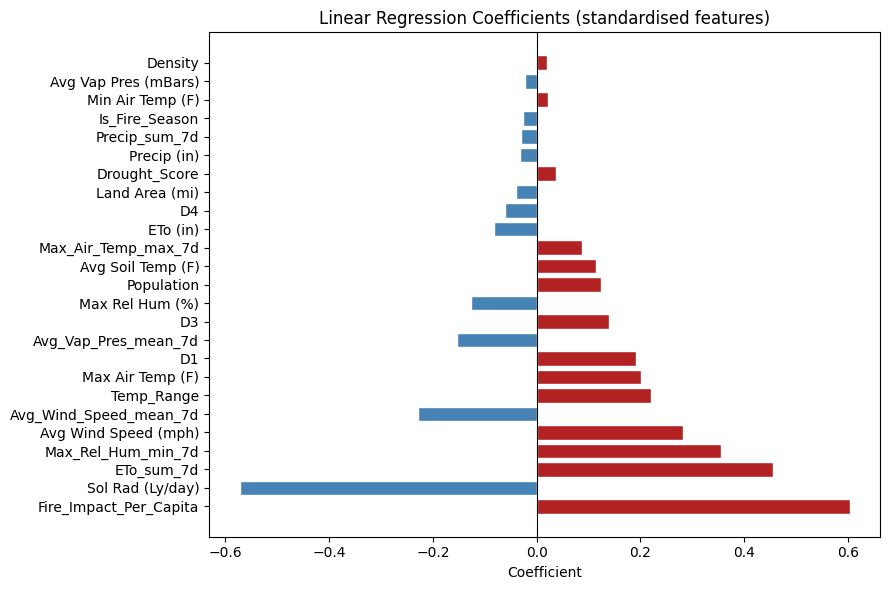

In [7]:
# Coefficients — what does linear regression think matters?
coef_df = pd.DataFrame({
    'feature': FEATURES,
    'coefficient': lr.coef_
}).sort_values('coefficient', key=abs, ascending=False)

plt.figure(figsize=(9, 6))
colors = ['firebrick' if v > 0 else 'steelblue' for v in coef_df['coefficient'].values]
plt.barh(coef_df['feature'], coef_df['coefficient'], color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Linear Regression Coefficients (standardised features)')
plt.xlabel('Coefficient')
plt.tight_layout()
plt.show()

## 5. Random Forest

In [8]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    max_features=0.6,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_preds = evaluate('Random Forest', rf, X_train, y_train, X_test, y_test)

--- Random Forest ---
  RMSE  train=0.3747   test=0.3882
  MAE   train=0.1646   test=0.2327
  R²    train=0.9740   test=0.9607


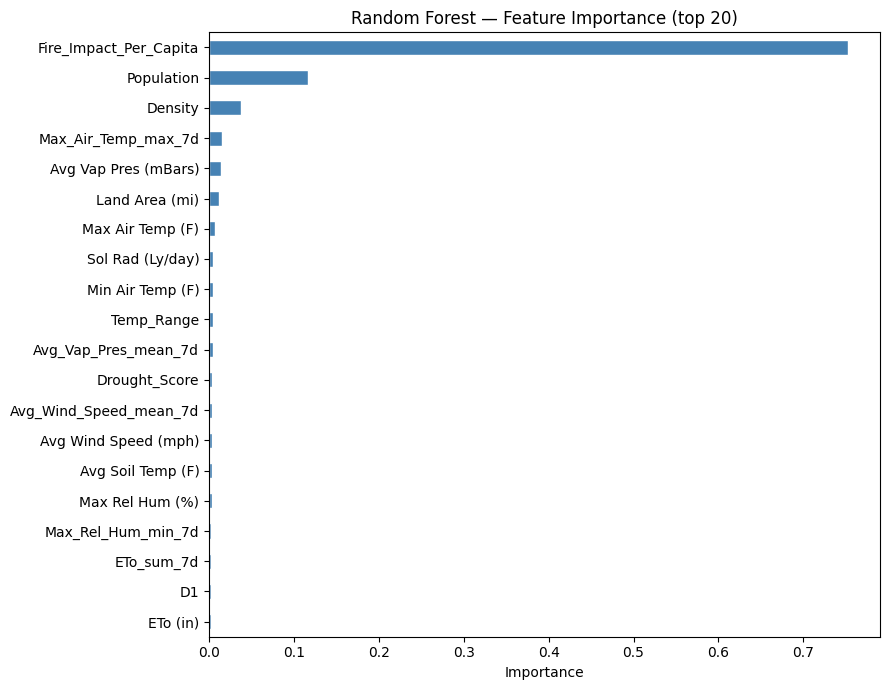

In [9]:
# Feature importance
fi_rf = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)

plt.figure(figsize=(9, 7))
fi_rf.tail(20).plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Random Forest — Feature Importance (top 20)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 6. XGBoost

In [10]:
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)
xgb_preds = evaluate('XGBoost', xgb, X_train, y_train, X_test, y_test)

--- XGBoost ---
  RMSE  train=0.0672   test=0.3245
  MAE   train=0.0468   test=0.1893
  R²    train=0.9992   test=0.9725


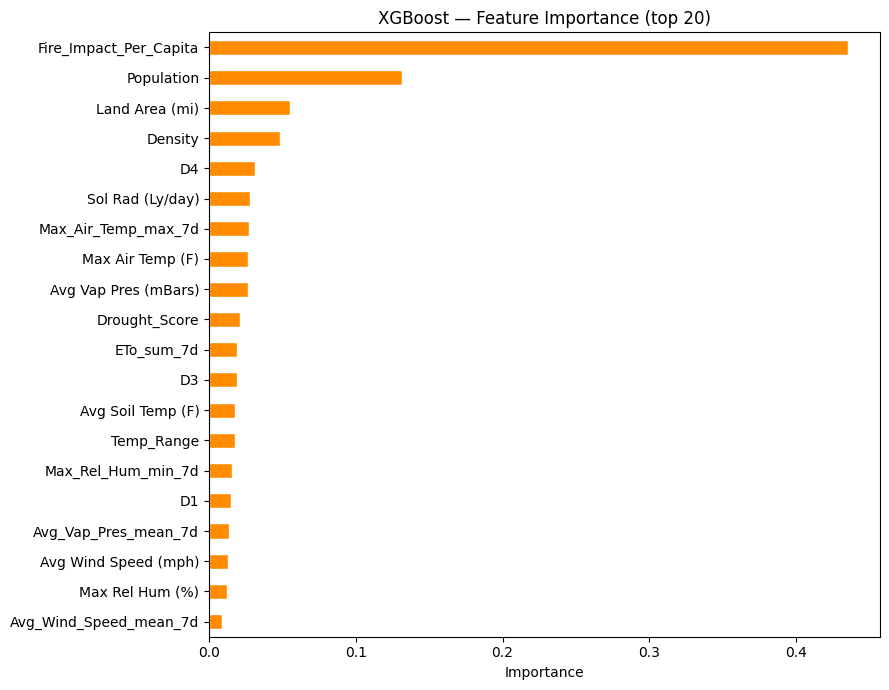

In [11]:
# Feature importance
fi_xgb = pd.Series(xgb.feature_importances_, index=FEATURES).sort_values(ascending=True)

plt.figure(figsize=(9, 7))
fi_xgb.tail(20).plot(kind='barh', color='darkorange', edgecolor='white')
plt.title('XGBoost — Feature Importance (top 20)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

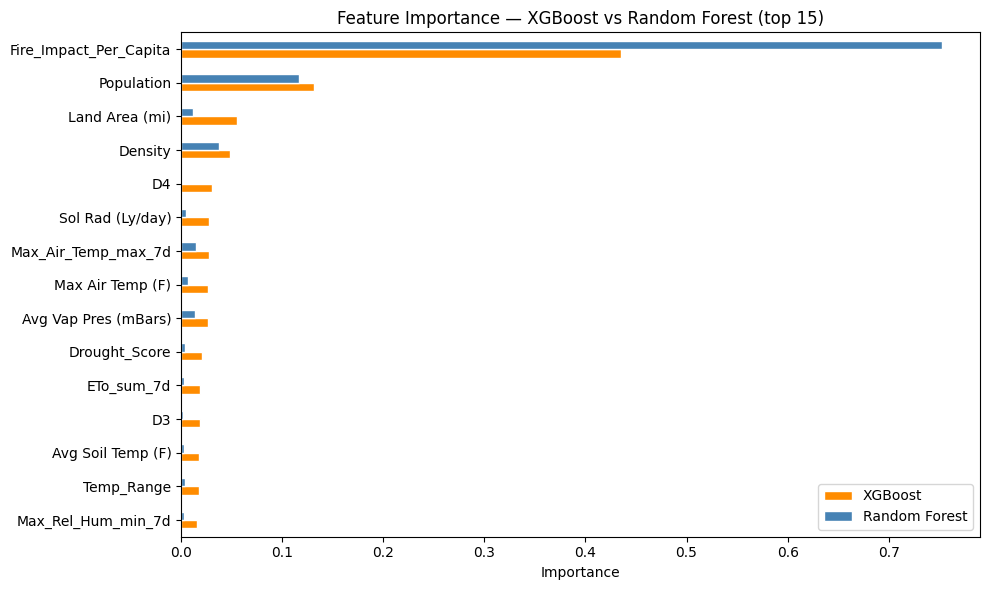

In [12]:
# Compare RF vs XGBoost feature importance side by side
top_features = fi_xgb.tail(15).index.tolist()
compare = pd.DataFrame({
    'XGBoost': fi_xgb[top_features],
    'Random Forest': fi_rf[top_features]
})

compare.sort_values('XGBoost').plot(kind='barh', figsize=(10, 6),
                                    color=['darkorange', 'steelblue'],
                                    edgecolor='white')
plt.title('Feature Importance — XGBoost vs Random Forest (top 15)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 7. Stacking Ensemble
Base learners: Random Forest + XGBoost
Meta-learner: Ridge Regression (trained on out-of-fold predictions)

In [13]:
estimators = [
    ('rf', RandomForestRegressor(
        n_estimators=300, max_depth=12, min_samples_leaf=5,
        max_features=0.6, random_state=42, n_jobs=-1
    )),
    ('xgb', XGBRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
        reg_lambda=1.0, random_state=42, n_jobs=-1, verbosity=0
    )),
]

stack = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(alpha=10),
    cv=5,
    n_jobs=-1
)

stack.fit(X_train, y_train)
stack_preds = evaluate('Stacking Ensemble', stack, X_train, y_train, X_test, y_test)

--- Stacking Ensemble ---
  RMSE  train=0.1059   test=0.3165
  MAE   train=0.0734   test=0.1890
  R²    train=0.9979   test=0.9739


## 8. Model Comparison

In [14]:
results_df = pd.DataFrame(results).T.round(4)
results_df = results_df[['R2_train', 'R2_test', 'RMSE_train', 'RMSE_test', 'MAE_train', 'MAE_test']]
results_df

,R2_train,R2_test,RMSE_train,RMSE_test,MAE_train,MAE_test
Baseline (mean),0.0000,-0.1575,2.3222,2.1067,1.7618,1.7819
Linear Regression,0.1812,-0.0894,2.1013,2.0438,1.6468,1.6962
Ridge Regression,0.1812,-0.0877,2.1013,2.0422,1.6468,1.6951
Random Forest,0.9740,0.9607,0.3747,0.3882,0.1646,0.2327
XGBoost,0.9992,0.9725,0.0672,0.3245,0.0468,0.1893
Stacking Ensemble,0.9979,0.9739,0.1059,0.3165,0.0734,0.1890


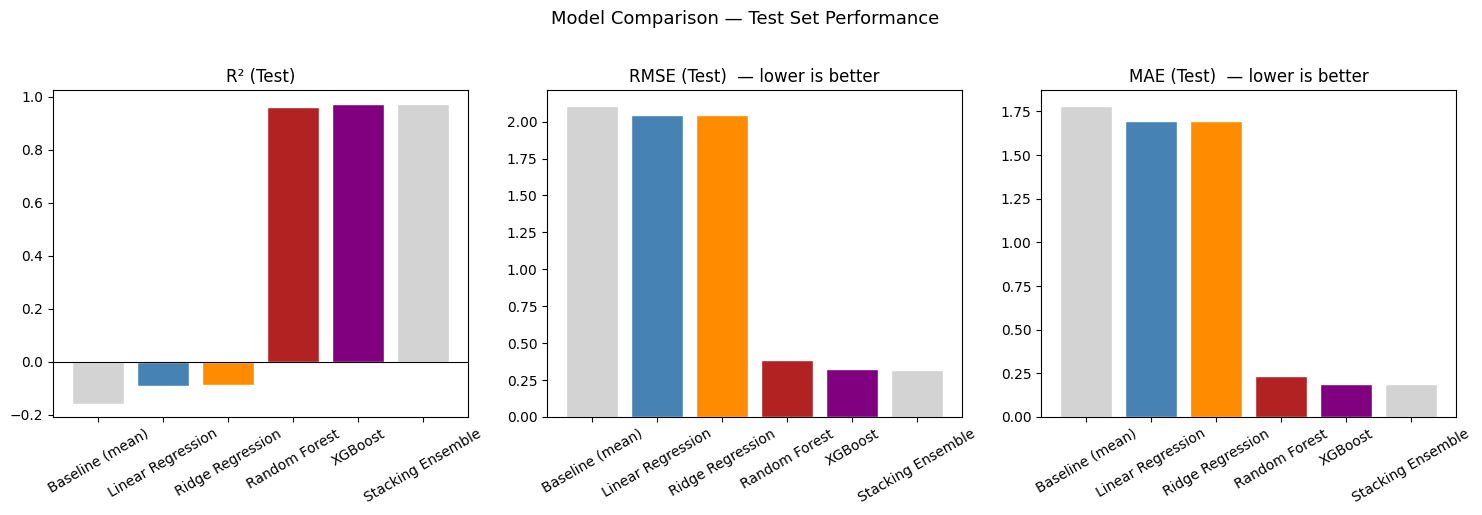

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models = list(results.keys())
r2_test   = [results[m]['R2_test']   for m in models]
rmse_test = [results[m]['RMSE_test'] for m in models]
mae_test  = [results[m]['MAE_test']  for m in models]

colors = ['lightgray', 'steelblue', 'darkorange', 'firebrick', 'purple']

axes[0].bar(models, r2_test, color=colors, edgecolor='white')
axes[0].set_title('R² (Test)')
axes[0].set_ylim(min(0, min(r2_test)) - 0.05, max(r2_test) + 0.05)
axes[0].tick_params(axis='x', rotation=30)
axes[0].axhline(0, color='black', linewidth=0.8)

axes[1].bar(models, rmse_test, color=colors, edgecolor='white')
axes[1].set_title('RMSE (Test)  — lower is better')
axes[1].tick_params(axis='x', rotation=30)

axes[2].bar(models, mae_test, color=colors, edgecolor='white')
axes[2].set_title('MAE (Test)  — lower is better')
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle('Model Comparison — Test Set Performance', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 9. Residual Analysis
Check where each model makes its biggest errors.

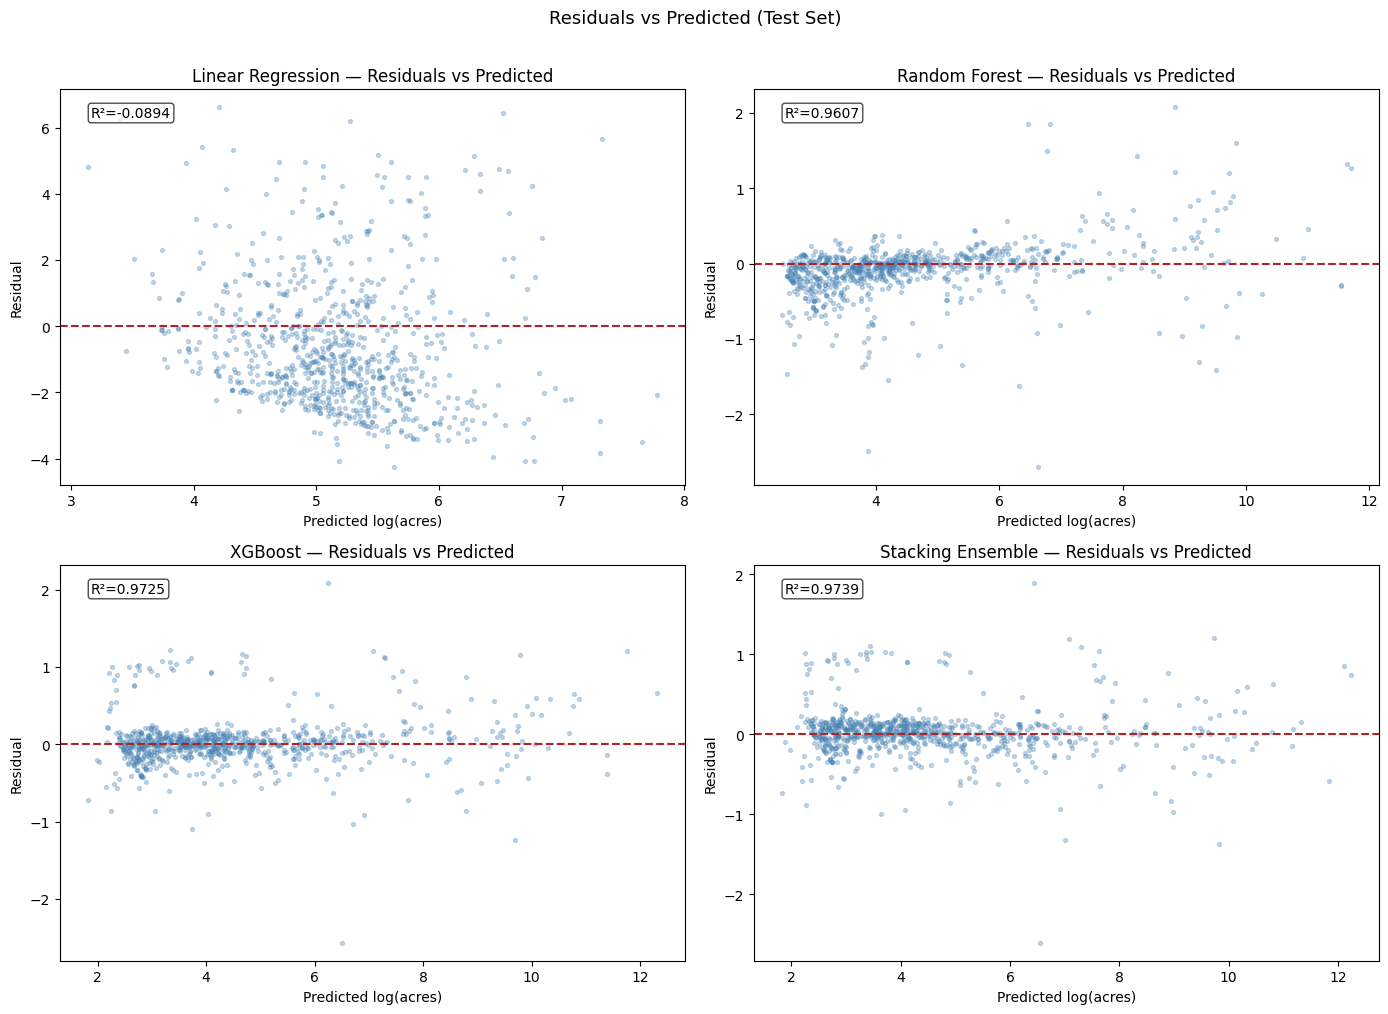

In [16]:
all_preds = {
    'Linear Regression': lr_preds,
    'Random Forest':     rf_preds,
    'XGBoost':           xgb_preds,
    'Stacking Ensemble': stack_preds,
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (name, preds) in enumerate(all_preds.items()):
    residuals = y_test.values - preds
    axes[i].scatter(preds, residuals, alpha=0.3, s=8, color='steelblue')
    axes[i].axhline(0, color='firebrick', linewidth=1.5, linestyle='--')
    axes[i].set_title(f'{name} — Residuals vs Predicted')
    axes[i].set_xlabel('Predicted log(acres)')
    axes[i].set_ylabel('Residual')
    r2 = results[name]['R2_test']
    axes[i].text(0.05, 0.93, f'R²={r2:.4f}', transform=axes[i].transAxes,
                 bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

plt.suptitle('Residuals vs Predicted (Test Set)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

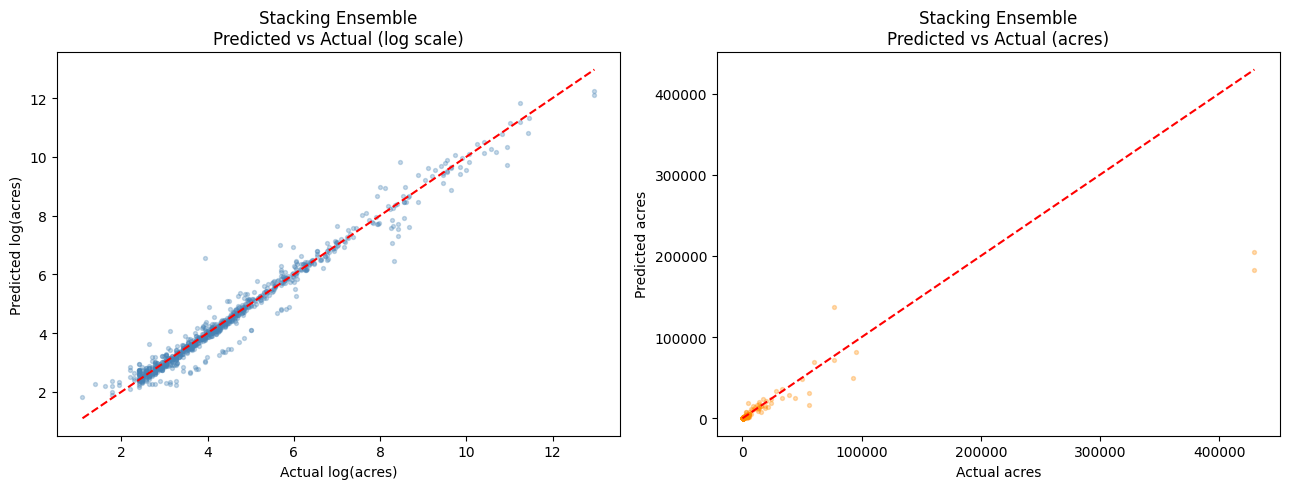

In [17]:
# Predicted vs actual for best model
best_model_name = max(results, key=lambda m: results[m]['R2_test'])
best_preds = all_preds.get(best_model_name, xgb_preds)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Log scale
axes[0].scatter(y_test, best_preds, alpha=0.3, s=8, color='steelblue')
mn, mx = min(y_test.min(), best_preds.min()), max(y_test.max(), best_preds.max())
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=1.5)
axes[0].set_title(f'{best_model_name}\nPredicted vs Actual (log scale)')
axes[0].set_xlabel('Actual log(acres)')
axes[0].set_ylabel('Predicted log(acres)')

# Back-transformed to acres
actual_acres = np.expm1(y_test)
pred_acres   = np.expm1(best_preds)
axes[1].scatter(actual_acres, pred_acres, alpha=0.3, s=8, color='darkorange')
mn2, mx2 = 0, max(actual_acres.max(), pred_acres.max())
axes[1].plot([mn2, mx2], [mn2, mx2], 'r--', linewidth=1.5)
axes[1].set_title(f'{best_model_name}\nPredicted vs Actual (acres)')
axes[1].set_xlabel('Actual acres')
axes[1].set_ylabel('Predicted acres')

plt.tight_layout()
plt.show()

In [18]:
# Worst predictions — where is the model most wrong?
test_copy = test.copy()
test_copy['predicted_log'] = best_preds
test_copy['actual_log']    = y_test.values
test_copy['abs_error']     = (test_copy['predicted_log'] - test_copy['actual_log']).abs()
test_copy['actual_acres']  = np.expm1(test_copy['actual_log'])
test_copy['pred_acres']    = np.expm1(test_copy['predicted_log'])

print(f'Worst 10 predictions ({best_model_name}):')
worst = test_copy.nlargest(10, 'abs_error')[[
    'County', 'Date', 'actual_acres', 'pred_acres', 'abs_error',
    'Drought_Score', 'Max_Air_Temp_max_7d'
]].round(2)
worst

Worst 10 predictions (Stacking Ensemble):


,County,Date,actual_acres,pred_acres,abs_error,Drought_Score,Max_Air_Temp_max_7d
1889,inyo,2022-10-23,50.0,692.23,2.61,304.16,86.2
1761,inyo,2022-02-16,4136.0,624.46,1.89,295.39,74.9
2250,modoc,2024-07-07,4685.0,18578.33,1.38,21.51,100.2
2334,mono,2024-07-23,292.0,1095.47,1.32,64.30,98.7
2470,los angeles,2024-09-08,56030.0,16757.49,1.21,0.00,113.4
1976,trinity,2023-08-15,3929.0,1188.99,1.19,0.94,99.2
2554,los angeles,2024-11-07,94.0,30.29,1.11,0.00,77.5
1820,calaveras,2022-07-04,4470.0,1489.98,1.10,408.99,97.0
1883,modoc,2022-09-07,5843.0,2049.39,1.05,313.61,101.9
1865,los angeles,2022-08-29,113.0,39.66,1.03,323.07,91.6


## 10. Final Summary

In [19]:
print('=' * 55)
print('FINAL MODEL COMPARISON — TEST SET')
print('=' * 55)
print(results_df[['R2_test', 'RMSE_test', 'MAE_test']].to_string())
print()

best = max(results, key=lambda m: results[m]['R2_test'])
print(f'Best model by R²: {best}')
print(f'  R²   = {results[best]["R2_test"]:.4f}')
print(f'  RMSE = {results[best]["RMSE_test"]:.4f}')
print(f'  MAE  = {results[best]["MAE_test"]:.4f}')
print()
print('Interpretation:')
print(f'  Predicting log(1+acres), so RMSE of {results[best]["RMSE_test"]:.2f} means')
print(f'  predictions are off by ~{results[best]["RMSE_test"]:.2f} on the log scale on average.')
r2 = results[best]['R2_test']
print(f'  R²={r2:.3f} means the model explains {r2*100:.1f}% of variance in log(acres).')

FINAL MODEL COMPARISON — TEST SET
                   R2_test  RMSE_test  MAE_test
Baseline (mean)    -0.1575     2.1067    1.7819
Linear Regression  -0.0894     2.0438    1.6962
Ridge Regression   -0.0877     2.0422    1.6951
Random Forest       0.9607     0.3882    0.2327
XGBoost             0.9725     0.3245    0.1893
Stacking Ensemble   0.9739     0.3165    0.1890

Best model by R²: Stacking Ensemble
  R²   = 0.9739
  RMSE = 0.3165
  MAE  = 0.1890

Interpretation:
  Predicting log(1+acres), so RMSE of 0.32 means
  predictions are off by ~0.32 on the log scale on average.
  R²=0.974 means the model explains 97.4% of variance in log(acres).


## 11. Risk Tier Analysis
Bin predictions and actuals into four tiers matching real-world dispatch categories.
This translates model output into something operationally meaningful.

In [20]:
# Risk tiers — based on real CAL FIRE incident size classifications
# Small:    < 100 acres   (initial attack, 1-2 engines)
# Moderate: 100–1K acres  (extended attack, multiple resources)
# Large:    1K–10K acres  (major incident, incident management team)
# Extreme:  > 10K acres   (complex fire, unified command)

TIER_BINS   = [0, 100, 1_000, 10_000, np.inf]
TIER_LABELS = ['Small\n(<100)', 'Moderate\n(100–1K)', 'Large\n(1K–10K)', 'Extreme\n(>10K)']
TIER_COLORS = ['steelblue', 'darkorange', 'firebrick', 'purple']

# Use best model predictions
actual_acres = np.expm1(y_test.values)
pred_acres   = np.expm1(stack_preds)

actual_tiers = pd.cut(actual_acres, bins=TIER_BINS, labels=TIER_LABELS)
pred_tiers   = pd.cut(pred_acres,   bins=TIER_BINS, labels=TIER_LABELS)

tier_df = pd.DataFrame({
    'actual_tier': actual_tiers,
    'pred_tier':   pred_tiers,
    'actual_acres': actual_acres,
    'pred_acres':   pred_acres,
})

# Exact tier match
exact_match = (tier_df['actual_tier'] == tier_df['pred_tier']).mean()

# Within-one-tier match (off by at most one tier)
tier_order = {t: i for i, t in enumerate(TIER_LABELS)}
tier_df['actual_idx'] = tier_df['actual_tier'].map(tier_order).astype(int)
tier_df['pred_idx']   = tier_df['pred_tier'].map(tier_order).astype(int)
within_one = (tier_df['actual_idx'] - tier_df['pred_idx']).abs().le(1).mean()

print(f'Exact tier match:       {exact_match*100:.1f}%')
print(f'Within one tier:        {within_one*100:.1f}%')
print()
print('Actual tier distribution (test set):')
print(tier_df['actual_tier'].value_counts().reindex(TIER_LABELS))
print()
print('Predicted tier distribution (test set):')
print(tier_df['pred_tier'].value_counts().reindex(TIER_LABELS))

Exact tier match:       95.9%
Within one tier:        100.0%

Actual tier distribution (test set):
actual_tier
Small\n(<100)         519
Moderate\n(100–1K)    207
Large\n(1K–10K)        60
Extreme\n(>10K)        34
Name: count, dtype: int64

Predicted tier distribution (test set):
pred_tier
Small\n(<100)         524
Moderate\n(100–1K)    201
Large\n(1K–10K)        59
Extreme\n(>10K)        36
Name: count, dtype: int64


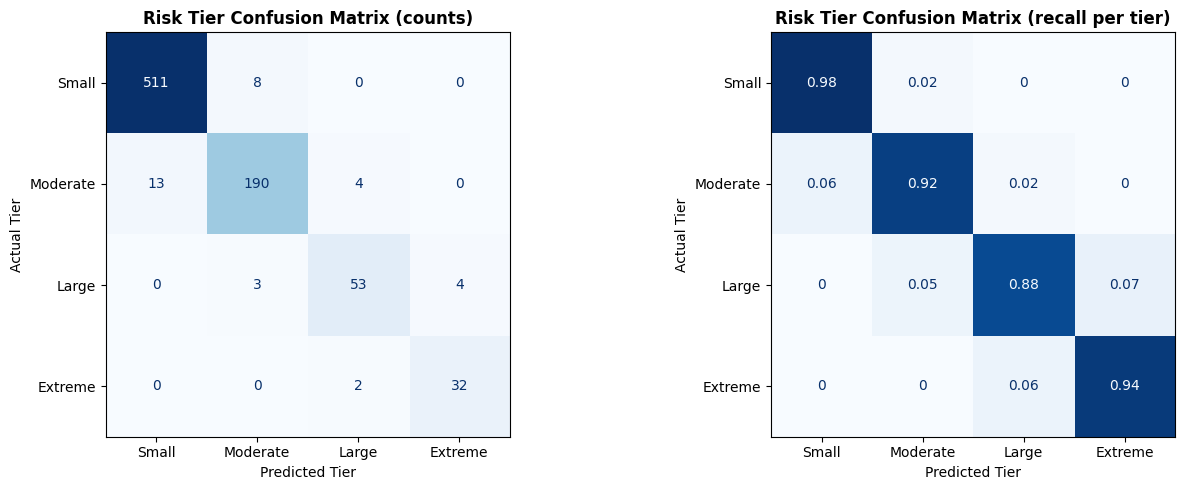

In [21]:
# Confusion matrix — actual tier vs predicted tier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

clean = tier_df.dropna(subset=['actual_tier', 'pred_tier'])
short_labels = ['Small', 'Moderate', 'Large', 'Extreme']

cm = confusion_matrix(clean['actual_tier'], clean['pred_tier'], labels=TIER_LABELS)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=short_labels)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Risk Tier Confusion Matrix (counts)', fontweight='bold')
axes[0].set_xlabel('Predicted Tier')
axes[0].set_ylabel('Actual Tier')

# Row-normalised (recall per tier)
cm_norm = cm.astype(float)
row_sums = cm_norm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm_norm, row_sums, where=row_sums != 0)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm.round(2), display_labels=short_labels)
disp2.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Risk Tier Confusion Matrix (recall per tier)', fontweight='bold')
axes[1].set_xlabel('Predicted Tier')
axes[1].set_ylabel('Actual Tier')

plt.tight_layout()
plt.show()

In [22]:
# Per-tier accuracy breakdown
print('Per-tier breakdown:')
print(f'{"Tier":<12} {"Actual Count":>13} {"Correct":>9} {"Recall":>8} {"Precision":>11}')
print('-' * 57)
for tier in TIER_LABELS:
    actual_mask = clean['actual_tier'] == tier
    pred_mask   = clean['pred_tier']   == tier
    true_pos    = (actual_mask & pred_mask).sum()
    actual_cnt  = actual_mask.sum()
    pred_cnt    = pred_mask.sum()
    recall    = true_pos / actual_cnt if actual_cnt > 0 else 0
    precision = true_pos / pred_cnt   if pred_cnt  > 0 else 0
    short = tier.split('\\n')[0]
    print(f'{short:<12} {actual_cnt:>13} {true_pos:>9} {recall:>7.1%} {precision:>11.1%}')

Per-tier breakdown:
Tier          Actual Count   Correct   Recall   Precision
---------------------------------------------------------
Small
(<100)           519       511   98.5%       97.5%
Moderate
(100–1K)           207       190   91.8%       94.5%
Large
(1K–10K)            60        53   88.3%       89.8%
Extreme
(>10K)            34        32   94.1%       88.9%


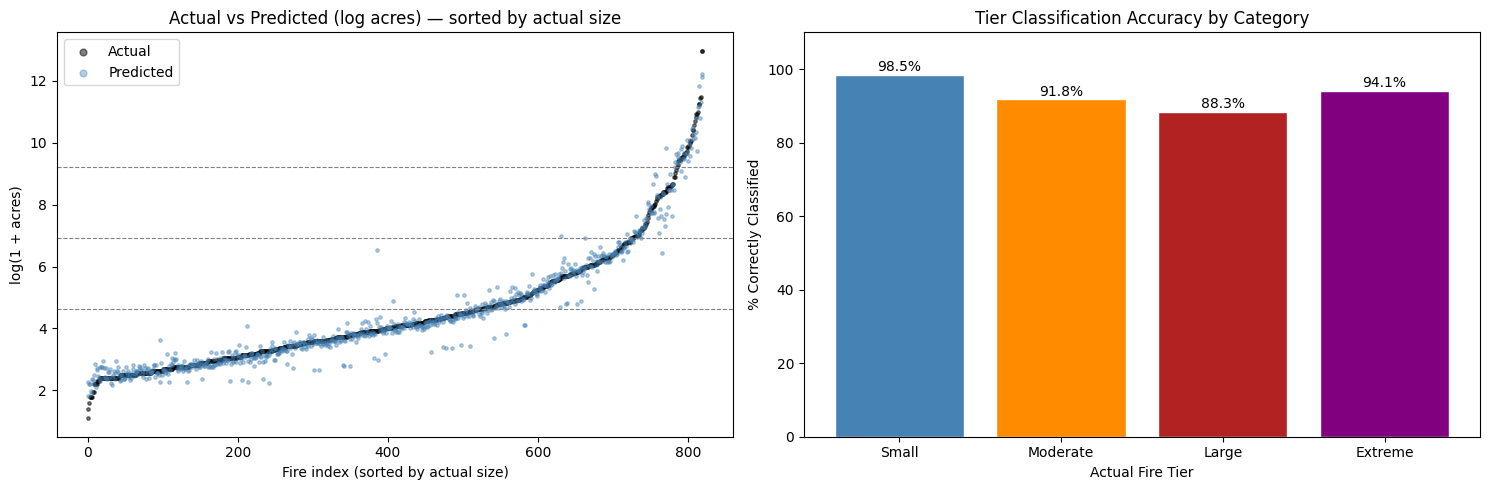

In [23]:
# Visual: actual vs predicted tier for every test fire, sorted by actual size
tier_df_sorted = tier_df.sort_values('actual_acres').reset_index(drop=True)
tier_df_sorted['match'] = tier_df_sorted['actual_tier'] == tier_df_sorted['pred_tier']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Predicted vs actual acres (log scale) coloured by whether tier matched
colors_match = ['steelblue' if m else 'firebrick' for m in tier_df_sorted['match']]
axes[0].scatter(range(len(tier_df_sorted)), np.log1p(tier_df_sorted['actual_acres']),
                s=6, alpha=0.5, color='black', label='Actual')
axes[0].scatter(range(len(tier_df_sorted)), np.log1p(tier_df_sorted['pred_acres']),
                s=6, alpha=0.4, color='steelblue', label='Predicted')

# Tier boundary lines
for bound in [np.log1p(100), np.log1p(1000), np.log1p(10000)]:
    axes[0].axhline(bound, color='gray', linewidth=0.8, linestyle='--')
axes[0].set_title('Actual vs Predicted (log acres) — sorted by actual size')
axes[0].set_xlabel('Fire index (sorted by actual size)')
axes[0].set_ylabel('log(1 + acres)')
axes[0].legend(markerscale=2)

# Tier match rate by actual tier as bar chart
match_rates = tier_df_sorted.groupby('actual_tier', observed=True)['match'].mean()
match_rates = match_rates.reindex(TIER_LABELS)
bars = axes[1].bar(short_labels, match_rates.values * 100,
                   color=TIER_COLORS, edgecolor='white')
for bar, val in zip(bars, match_rates.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val*100:.1f}%', ha='center', fontsize=10)
axes[1].set_ylim(0, 110)
axes[1].set_title('Tier Classification Accuracy by Category')
axes[1].set_ylabel('% Correctly Classified')
axes[1].set_xlabel('Actual Fire Tier')

plt.tight_layout()
plt.show()

In [24]:
# Summary framing — what this means operationally
print('=' * 60)
print('RISK TIER SUMMARY — Stacking Ensemble on Test Set')
print('=' * 60)
print(f'''
Exact tier match:    {exact_match*100:.1f}% of fires placed in correct tier
Within one tier:     {within_one*100:.1f}% of fires within one tier of correct

Operational interpretation:
  Given weather + drought conditions at time of ignition,
  the model correctly categorises fire scale {exact_match*100:.0f}% of the time.
  In {within_one*100:.0f}% of cases it is at most one tier off —
  e.g. predicting Large when the fire was actually Extreme.

Dispatch tiers:
  Small    (<100 acres)   — initial attack, 1-2 engines
  Moderate (100-1K acres) — extended attack, multiple resources  
  Large    (1K-10K acres) — major incident, type 2 team
  Extreme  (>10K acres)   — complex fire, unified command
''')

RISK TIER SUMMARY — Stacking Ensemble on Test Set

Exact tier match:    95.9% of fires placed in correct tier
Within one tier:     100.0% of fires within one tier of correct

Operational interpretation:
  Given weather + drought conditions at time of ignition,
  the model correctly categorises fire scale 96% of the time.
  In 100% of cases it is at most one tier off —
  e.g. predicting Large when the fire was actually Extreme.

Dispatch tiers:
  Small    (<100 acres)   — initial attack, 1-2 engines
  Moderate (100-1K acres) — extended attack, multiple resources  
  Large    (1K-10K acres) — major incident, type 2 team
  Extreme  (>10K acres)   — complex fire, unified command

